# 🎢 Roller Coaster Database — Exploratory Data Analysis

A quick EDA on `coaster_db.csv` (1,087 roller coasters, historic and modern, worldwide): load and inspect the data, clean it up, then look at how coasters have changed over time and how speed, height, inversions and G-force relate to each other.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap

BG, FG, GRID = "#010A19", "#EEF2F7", "#33405C"
TEAL, PURPLE, CORAL, AMBER = "#60F5D2", "#D6B2FC", "#FF7A90", "#F6E27F"

sns.set_theme(
    style="dark",
    context="notebook",
    rc={
        "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
        "axes.edgecolor": GRID, "axes.labelcolor": FG, "axes.titlecolor": FG,
        "axes.titlesize": 14, "axes.titleweight": "bold",
        "axes.grid": True, "axes.axisbelow": True,
        "grid.color": GRID, "grid.linewidth": 0.7,
        "text.color": FG, "xtick.color": FG, "ytick.color": FG,
        "legend.facecolor": BG, "legend.edgecolor": GRID, "legend.labelcolor": FG,
    },
)

IMG_DIR = Path("images")
IMG_DIR.mkdir(exist_ok=True)


def save_fig(fig, name):
    """Save a figure to images/ so the README can reuse it."""
    fig.savefig(IMG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

## 2. Load & Inspect

In [2]:
DATA_PATH = Path("data/coaster_db.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} not found. Run this notebook from the repository root "
        "(see the README, section \'Data\')."
    )

df = pd.read_csv(DATA_PATH)
df.head()

,coaster_name,Length,Speed,Location,Status,Opening date,Type,Manufacturer,Height restriction,Model,...,speed1,speed2,speed1_value,speed1_unit,speed_mph,height_value,height_unit,height_ft,Inversions_clean,Gforce_clean
0,Switchback Railway,600 ft (180 m),6 mph (9.7 km/h),Coney Island,Removed,"June 16, 1884",Wood,LaMarcus Adna Thompson,NaN,Lift Packed,...,6 mph,9.7 km/h,6.0,mph,6.0,50.0,ft,NaN,0,2.9
1,Flip Flap Railway,NaN,NaN,Sea Lion Park,Removed,1895,Wood,Lina Beecher,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,12.0
2,Switchback Railway (Euclid Beach Park),NaN,NaN,"Cleveland, Ohio, United States",Closed,NaN,Other,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,Loop the Loop (Coney Island),NaN,NaN,Other,Removed,1901,Steel,Edwin Prescott,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
4,Loop the Loop (Young's Pier),NaN,NaN,Other,Removed,1901,Steel,Edwin Prescott,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN


In [3]:
df.shape

(1087, 56)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1087 entries, 0 to 1086
Data columns (total 56 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   coaster_name                   1087 non-null   str    
 1   Length                         953 non-null    str    
 2   Speed                          937 non-null    str    
 3   Location                       1087 non-null   str    
 4   Status                         874 non-null    str    
 5   Opening date                   837 non-null    str    
 6   Type                           1087 non-null   str    
 7   Manufacturer                   1028 non-null   str    
 8   Height restriction             831 non-null    str    
 9   Model                          744 non-null    str    
 10  Height                         965 non-null    str    
 11  Inversions                     932 non-null    float64
 12  Lift/launch system             795 non-null    str    
 13 

In [5]:
df.describe(include="all")

,coaster_name,Length,Speed,Location,Status,Opening date,Type,Manufacturer,Height restriction,Model,...,speed1,speed2,speed1_value,speed1_unit,speed_mph,height_value,height_unit,height_ft,Inversions_clean,Gforce_clean
count,1087,953,937,1087,874,837,1087,1028,831,744,...,937,935,937.000000,937,937.000000,965.000000,965,171.000000,1087.000000,362.000000
unique,990,569,243,280,15,656,98,102,100,317,...,225,229,NaN,2,NaN,NaN,2,NaN,NaN,NaN
top,Batman: The Ride,935 ft (285 m),50 mph (80 km/h),Other,Operating,1972,Steel,Vekoma,48 in (122 cm),Custom,...,50 mph,80 km/h,NaN,mph,NaN,NaN,ft,NaN,NaN,NaN
freq,7,21,63,250,668,7,308,135,224,20,...,63,63,NaN,780,NaN,NaN,794,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,53.850374,NaN,48.617289,89.575171,NaN,101.996491,1.326587,3.824006
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,23.385518,NaN,16.678031,136.246444,NaN,67.329092,2.030854,0.989998
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,5.000000,NaN,5.000000,4.000000,NaN,13.100000,0.000000,0.800000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,40.000000,NaN,37.300000,44.000000,NaN,51.800000,0.000000,3.400000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,50.000000,NaN,49.700000,79.000000,NaN,91.200000,0.000000,4.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,63.000000,NaN,58.000000,113.000000,NaN,131.200000,2.000000,4.500000


In [6]:
df.dtypes

coaster_name                         str
Length                               str
Speed                                str
Location                             str
Status                               str
Opening date                         str
Type                                 str
Manufacturer                         str
Height restriction                   str
Model                                str
Height                               str
Inversions                       float64
Lift/launch system                   str
Cost                                 str
Trains                               str
Park section                         str
Duration                             str
Capacity                             str
G-force                              str
Designer                             str
Max vertical angle                   str
Drop                                 str
Soft opening date                    str
Fast Lane available                  str
Replaced        

In [7]:
df.columns

Index(['coaster_name', 'Length', 'Speed', 'Location', 'Status', 'Opening date',
       'Type', 'Manufacturer', 'Height restriction', 'Model', 'Height',
       'Inversions', 'Lift/launch system', 'Cost', 'Trains', 'Park section',
       'Duration', 'Capacity', 'G-force', 'Designer', 'Max vertical angle',
       'Drop', 'Soft opening date', 'Fast Lane available', 'Replaced',
       'Track layout', 'Fastrack available', 'Soft opening date.1',
       'Closing date', 'Opened', 'Replaced by', 'Website',
       'Flash Pass Available', 'Must transfer from wheelchair', 'Theme',
       'Single rider line available', 'Restraint Style',
       'Flash Pass available', 'Acceleration', 'Restraints', 'Name',
       'year_introduced', 'latitude', 'longitude', 'Type_Main',
       'opening_date_clean', 'speed1', 'speed2', 'speed1_value', 'speed1_unit',
       'speed_mph', 'height_value', 'height_unit', 'height_ft',
       'Inversions_clean', 'Gforce_clean'],
      dtype='str')

## 3. Clean & Prepare

In [8]:
df = df[[
    "coaster_name",
    "Location",
    "Status",
    "Manufacturer",
    "year_introduced",
    "latitude",
    "longitude",
    "Type_Main",
    "opening_date_clean",
    "speed_mph",
    "height_ft",
    "Inversions_clean",
    "Gforce_clean",
]].copy()

In [9]:
df["opening_date_clean"] = pd.to_datetime(df["opening_date_clean"])

In [10]:
df = df.rename(columns={
    "coaster_name": "Coaster_Name",
    "year_introduced": "Year_Introduced",
    "opening_date_clean": "Opening_Date",
    "speed_mph": "Speed_mph",
    "height_ft": "Height_ft",
    "Inversions_clean": "Inversions",
    "Gforce_clean": "Gforce",
})
df.head()

,Coaster_Name,Location,Status,Manufacturer,Year_Introduced,latitude,longitude,Type_Main,Opening_Date,Speed_mph,Height_ft,Inversions,Gforce
0,Switchback Railway,Coney Island,Removed,LaMarcus Adna Thompson,1884,40.5740,-73.9780,Wood,1884-06-16,6.0,NaN,0,2.9
1,Flip Flap Railway,Sea Lion Park,Removed,Lina Beecher,1895,40.5780,-73.9790,Wood,1895-01-01,NaN,NaN,1,12.0
2,Switchback Railway (Euclid Beach Park),"Cleveland, Ohio, United States",Closed,NaN,1896,41.5800,-81.5700,Other,NaT,NaN,NaN,0,NaN
3,Loop the Loop (Coney Island),Other,Removed,Edwin Prescott,1901,40.5745,-73.9780,Steel,1901-01-01,NaN,NaN,1,NaN
4,Loop the Loop (Young's Pier),Other,Removed,Edwin Prescott,1901,39.3538,-74.4342,Steel,1901-01-01,NaN,NaN,1,NaN


## 4. Remove Duplicate Coasters

⚠️ **Fix:** the original check (same `Coaster_Name` + `Location` + `Opening_Date`) treated many *different* coasters as duplicates, because `Location` falls back to `"Other"` and `Opening_Date` is missing for a lot of rows — so two unrelated coasters that just share a name (e.g. **Batman: The Ride**, a Bolliger & Mabillard model built at several different Six Flags parks) would both have `Location = "Other"` and `Opening_Date = NaT`, and looked identical on those three columns even though they're not the same ride. That alone was silently dropping **66 real coasters** (e.g. only 1 of 4 "Big Thunder Mountain Railroad" installations survived).

The fix below only treats rows as duplicates when they actually agree on a *known* location and a *known* date — so a real repeat (same coaster, same park, same date, listed twice) still gets removed, but two different coasters that merely share a name no longer collide.

In [11]:
rows_before = len(df)

has_known_location_and_date = (df["Location"] != "Other") & df["Opening_Date"].notna()
is_duplicate = has_known_location_and_date & df.duplicated(
    subset=["Coaster_Name", "Location", "Opening_Date"], keep="first"
)

df = df.loc[~is_duplicate].reset_index(drop=True).copy()

print(f"Rows before: {rows_before} | after removing true duplicates: {len(df)} "
      f"| duplicates removed: {rows_before - len(df)}")

Rows before: 1087 | after removing true duplicates: 1060 | duplicates removed: 27


## 5. Univariate Analysis

In [12]:
df["Year_Introduced"].value_counts()

Year_Introduced
1999    49
2000    47
1998    32
2011    31
2001    30
        ..
1952     1
1955     1
1956     1
1959     1
1961     1
Name: count, Length: 101, dtype: int64

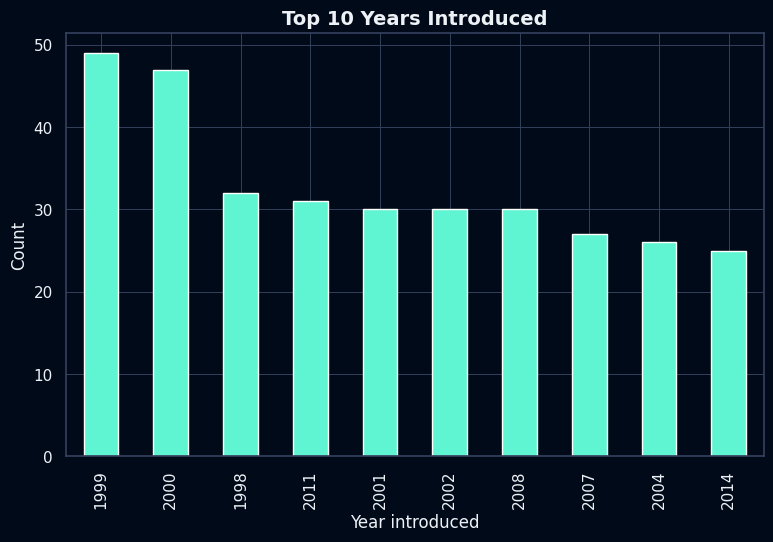

In [13]:
ax1 = (df["Year_Introduced"].value_counts()
       .head(10)
       .plot(kind="bar", title="Top 10 Years Introduced", color=TEAL, figsize=(9, 5.5)))
ax1.set_xlabel("Year introduced")
ax1.set_ylabel("Count")
save_fig(ax1.figure, "01_top10_years")
plt.show()

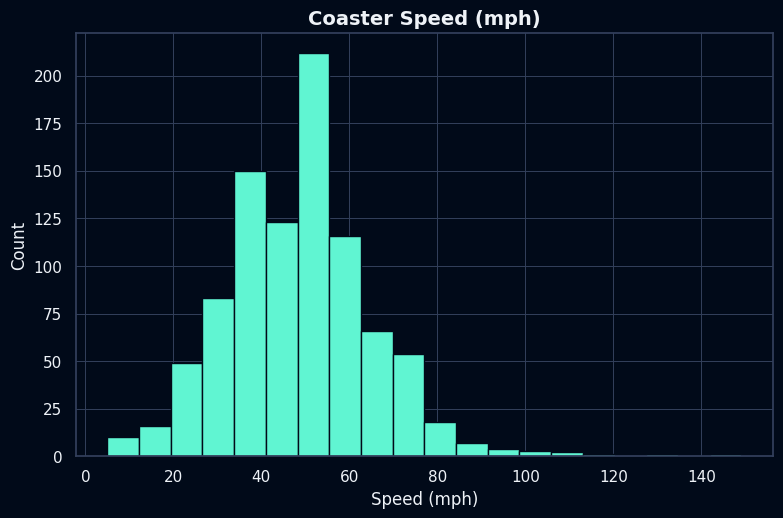

In [14]:
ax2 = df["Speed_mph"].plot(kind="hist", bins=20, title="Coaster Speed (mph)",
                            color=TEAL, edgecolor=BG, figsize=(9, 5.5))
ax2.set_xlabel("Speed (mph)")
ax2.set_ylabel("Count")
save_fig(ax2.figure, "02_speed_distribution")
plt.show()

## 6. Bivariate & Multivariate Analysis

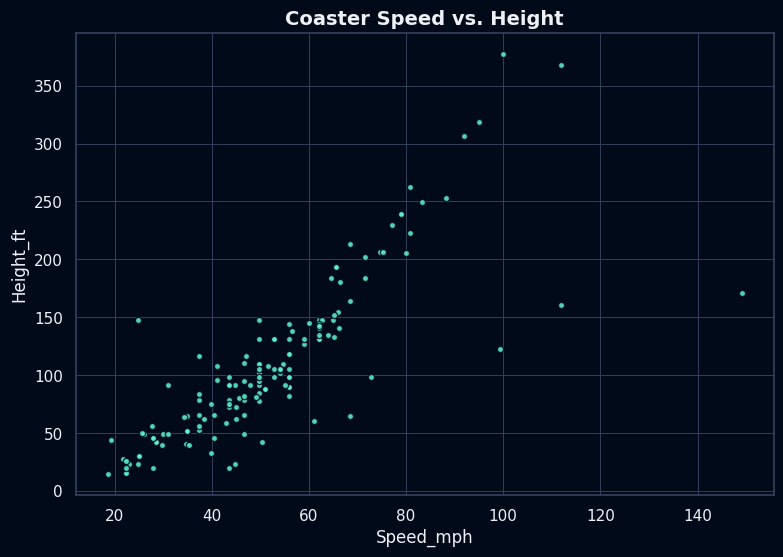

In [15]:
ax3 = df.plot(kind="scatter", x="Speed_mph", y="Height_ft", title="Coaster Speed vs. Height",
              color=TEAL, edgecolor=BG, alpha=0.85, figsize=(9, 6))
save_fig(ax3.figure, "03_speed_vs_height")
plt.show()

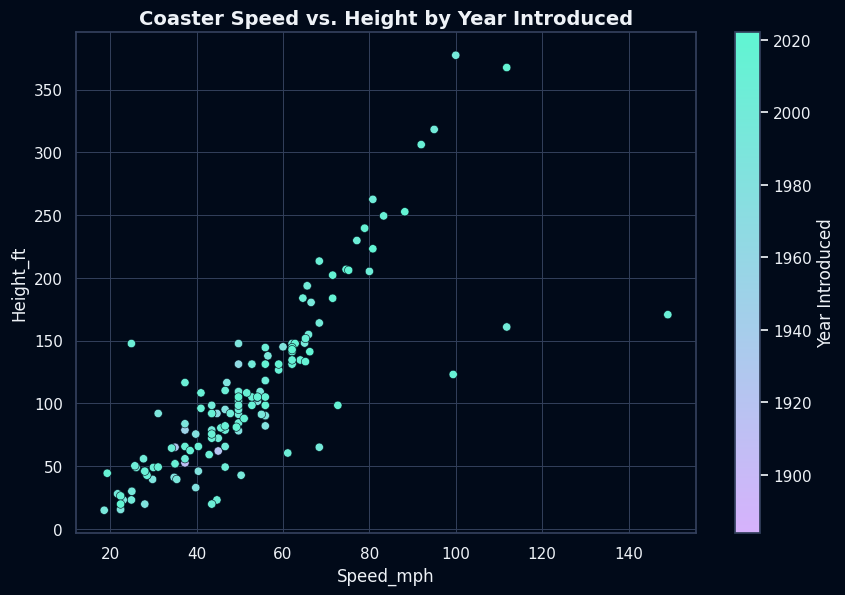

In [16]:
# Year_Introduced is continuous, so it gets a purple-to-teal colour scale with a colourbar
# instead of one legend entry per year.
brand_cmap = LinearSegmentedColormap.from_list("brand", [PURPLE, TEAL])

fig, ax = plt.subplots(figsize=(10, 6.5))
sns.scatterplot(x="Speed_mph", y="Height_ft", hue="Year_Introduced", palette=brand_cmap,
                 data=df, edgecolor=BG, linewidth=0.4, ax=ax, legend=False)
ax.set_title("Coaster Speed vs. Height by Year Introduced")

norm = plt.Normalize(df["Year_Introduced"].min(), df["Year_Introduced"].max())
sm = plt.cm.ScalarMappable(cmap=brand_cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Year Introduced", color=FG)
cbar.ax.yaxis.set_tick_params(color=FG)
plt.setp(cbar.ax.get_yticklabels(), color=FG)

save_fig(fig, "04_speed_height_by_year")
plt.show()

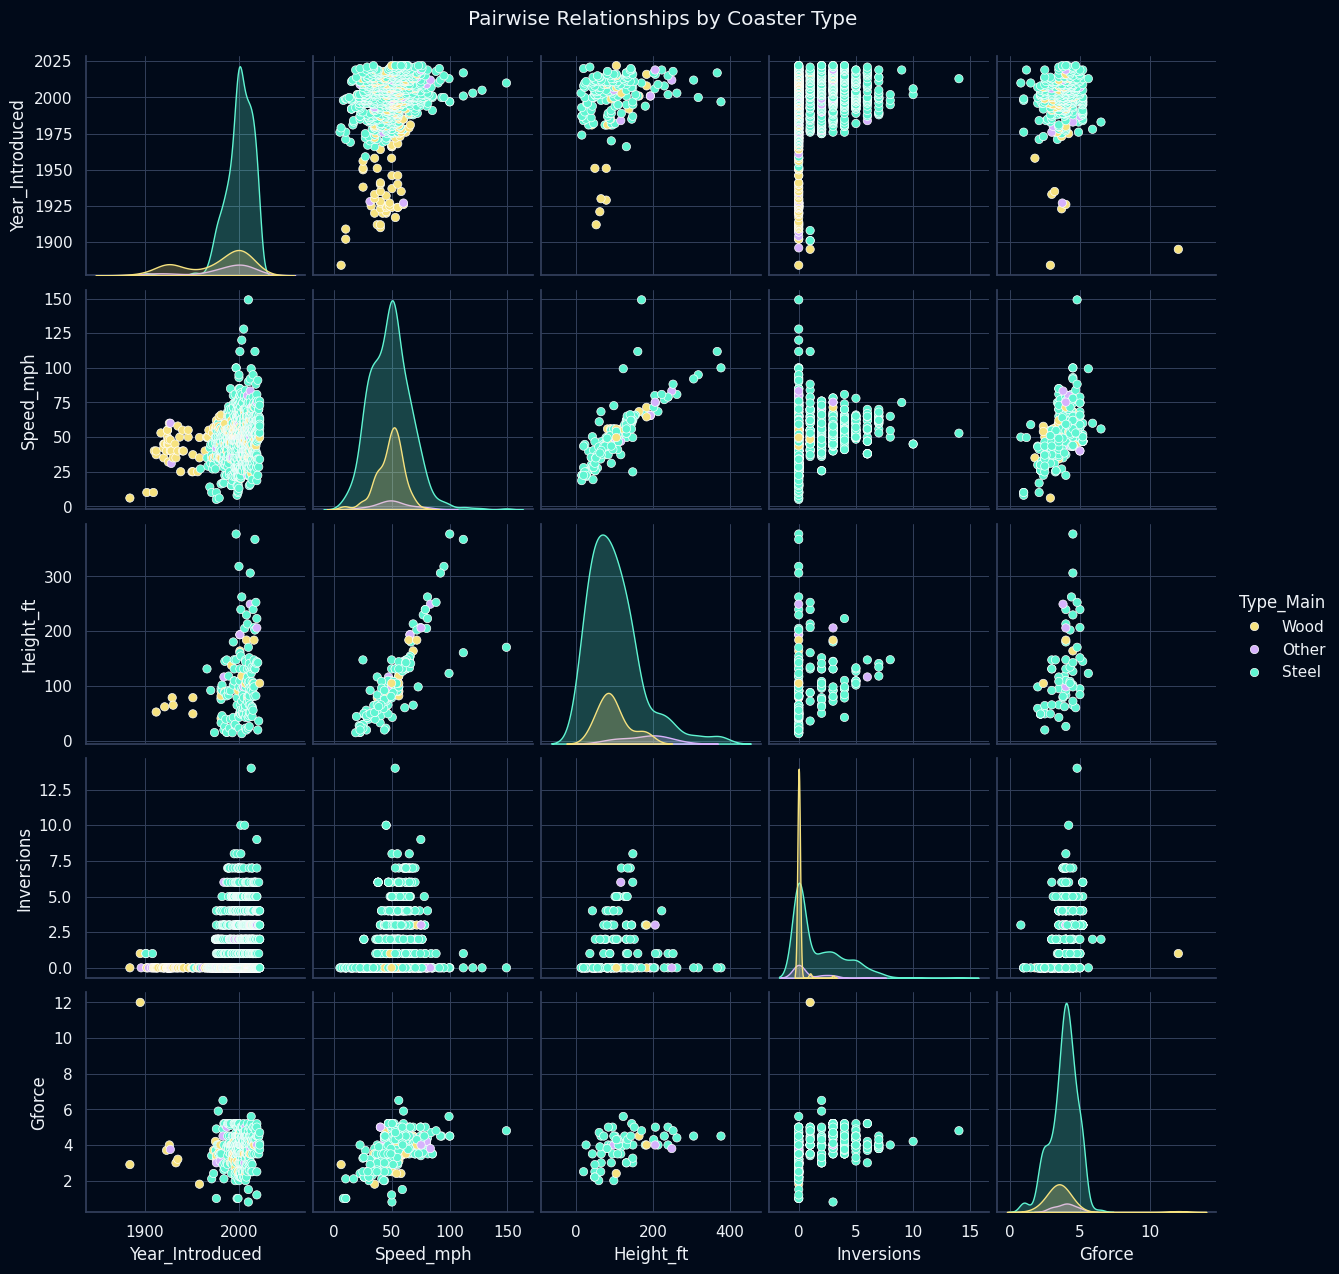

In [17]:
g = sns.pairplot(df, vars=["Year_Introduced", "Speed_mph", "Height_ft", "Inversions", "Gforce"],
                  hue="Type_Main", palette={"Wood": AMBER, "Steel": TEAL, "Other": PURPLE})
g.figure.suptitle("Pairwise Relationships by Coaster Type", y=1.02, color=FG)
for ax in g.axes.flatten():
    if ax is not None:
        ax.set_facecolor(BG)

save_fig(g.figure, "05_pairplot_by_type")
plt.show()

## 7. Correlation

In [18]:
# Height_ft and Gforce are recorded for a fairly small share of coasters, so check
# that before trusting the correlation numbers below.
numeric_cols = ["Year_Introduced", "Speed_mph", "Height_ft", "Inversions", "Gforce"]
df[numeric_cols].isna().sum()

Year_Introduced      0
Speed_mph          144
Height_ft          894
Inversions           0
Gforce             707
dtype: int64

In [19]:
df_corr = df[numeric_cols].dropna().corr()
print(f"Correlation is computed on {len(df[numeric_cols].dropna())} of {len(df)} coasters "
      "(the ones with all five values present) — treat it as a rough signal, not a precise estimate.")
df_corr

Correlation is computed on 68 of 1060 coasters (the ones with all five values present) — treat it as a rough signal, not a precise estimate.


,Year_Introduced,Speed_mph,Height_ft,Inversions,Gforce
Year_Introduced,1.000000,0.173057,0.134530,-0.210710,0.166910
Speed_mph,0.173057,1.000000,0.733600,-0.029139,0.605449
Height_ft,0.134530,0.733600,1.000000,-0.079550,0.461977
Inversions,-0.210710,-0.029139,-0.079550,1.000000,0.271467
Gforce,0.166910,0.605449,0.461977,0.271467,1.000000


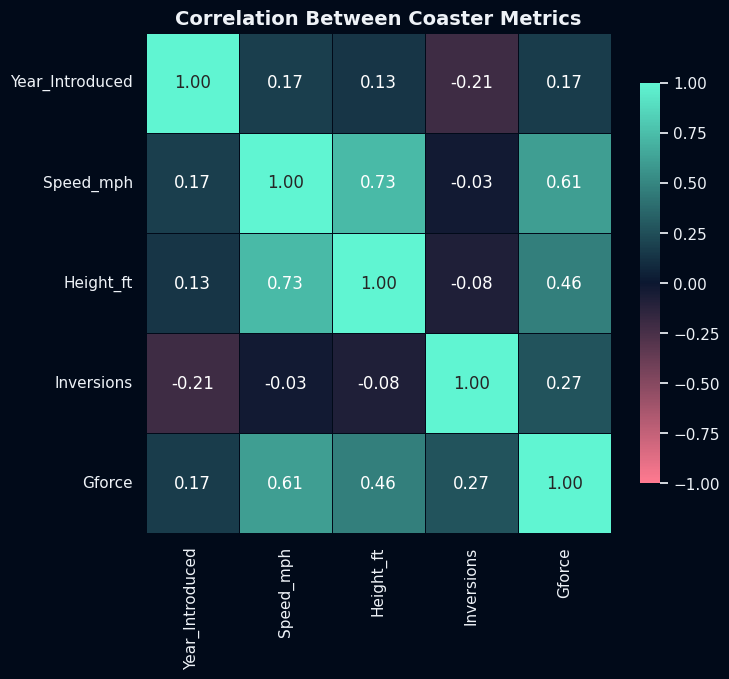

In [20]:
div_cmap = LinearSegmentedColormap.from_list("brand_diverging", [CORAL, "#0B1730", TEAL])

fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap=div_cmap, center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor=BG, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation Between Coaster Metrics")
ax.grid(False)

save_fig(fig, "06_correlation_heatmap")
plt.show()

## 8. Conclusions & Key Insights

1. **Fixing the duplicate check mattered.** The corrected logic in Section 4 changed the cleaned dataset from 990 rows (the original name-only match) to 1,060 — 70 more real coasters kept, including every installation of rides built at multiple parks (all 7 "Batman: The Ride" clones and all 4 "Big Thunder Mountain Railroad" versions, which the original check had each collapsed down to one).
2. **Speed, height and G-force move together.** Speed and height are closely linked (r = 0.73), and G-force tracks both (r = 0.61 with speed, r = 0.46 with height) — taller, faster coasters pull harder.
3. **Inversions are a separate story.** They're essentially unrelated to speed (r = -0.03), so a loopy coaster isn't necessarily a fast one, and they go with slightly *older* coasters (r = -0.21 with year introduced) rather than newer ones.
4. **1999 and 2000 were peak years.** They're the two biggest years for new coasters in the dataset (49 and 47), part of a construction boom that ran through the late 1990s and 2000s.
5. **Read the correlations with caution.** They're built from only 68 of 1,060 coasters (6%) — the ones with speed, height, inversions *and* G-force all recorded. `Height_ft` alone is missing for 894 coasters, mostly older wood coasters that were never measured that way, so treat those relationships as a rough signal rather than a precise estimate.

A natural next step would be cleaning the `Status` column to compare operating vs. retired coasters, bringing in `Manufacturer` or `Park section` for a builder- or park-level view, or modeling `Speed_mph` from height, inversions and year introduced.